In [14]:
from pathlib import Path
import copy
import math
import os
import sys

import fpsample
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import seaborn as sns
import yaml
from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from tqdm import tqdm

sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

## Initialize columns to keep 

In [15]:
# Cell type fractions
celltype_fraction = {
    "CD16Mono": 0.05, 
    "CD14Mono": 0.05
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
     'tpo_[ng_ml]',
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]',
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]',
     'il3_[ng_ml]',
     'o2_[%]',
     'days_of_culture',
     'run_name',
     "cfg:constraints:c_scheduler_kwargs:t_warmup",
     "cfg:constraints:c_scheduler_kwargs:vmin",
     "cfg:constraints:c_scheduler_kwargs:vmax",

]

columns_of_interest_l4 =  columns_of_interest + ["il7_[ng_ml]",
                                                 "mcsf_[ng_ml]",
                                                 "ly_cocktail_[ul/well]", 
                                                 "loss", 
                                                 "target_ct_loss_std",
                                                 "target_ct_loss_mean",
                                                 "ct_prop_total_variance"]

## Load solutions 

In [16]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
    load_uncertainties=True
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                if load_uncertainties:
                    uncertainty_path = (
                        exp_folder
                        / "uncertainty_annotation"
                        / "candidates_with_uncertainties.csv"
                    )

                else:
                    uncertainty_path = (
                        exp_folder
                        / "candidates.csv"
                    )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():
 
                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [17]:
# Read annotation files
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols_l4 = protocol_cols + ['il7_[ng_ml]','mcsf_[ng_ml]','ly_cocktail_[ul/well]']

# Read constraint files
ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop4.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_l4 = yaml.safe_load(fb)
ubound_dict_l4, lbound_dict_l4 = annotation_cfg_bound_l4["ubound_dict"],  annotation_cfg_bound_l4["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

bounds_l4 = {}
for param in lbound_dict_l4:
    bounds_l4[param] = (lbound_dict_l4[param], ubound_dict_l4[param])

### Collect optimized samples 

In [18]:
path_to_results_loop4 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop3_replicate")
paths_loop4 = os.listdir(path_to_results_loop4)

In [19]:
cell_types = ["CD14Mono", "CD16Mono"]

raw_solutions_loop4 = load_pure_cell_type_solutions(
    path_to_results_loop4,
    paths_loop4,
    cell_types,
    load_uncertainties=True
)

100%|██████████| 6/6 [00:58<00:00,  9.74s/it]


In [20]:
raw_solutions_loop4 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop4.items()
}

In [21]:
cd14 = raw_solutions_loop4["CD14Mono"]
cd16 = raw_solutions_loop4["CD16Mono"]

In [22]:
print(cd16["CD16Mono_prop"].max())

0.56337565


In [23]:
# Collect filtered and annotated data frames 
filtered_df_cd16, annotated_df_cd16 = manual_filtering(
    df_dict={"CD16Mono": cd16},
    bounds=bounds_l4,
    columns_to_keep=columns_of_interest_l4, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_l4,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=False
)
cd16 = filtered_df_cd16["CD16Mono"]

## Check heatmaps

In [24]:
cd16_prot = np.log1p(cd16.loc[:, protocol_cols_l4])
cd16_prop = cd16["CD16Mono_prop"]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


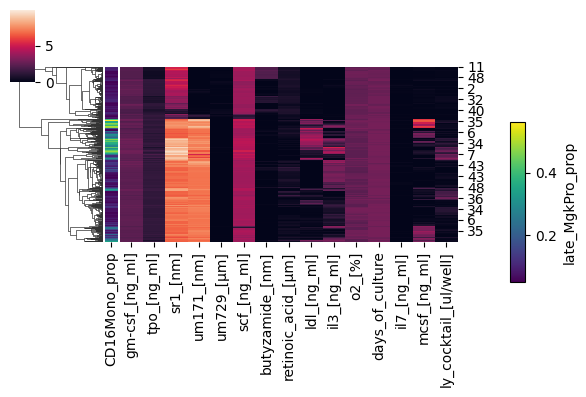

In [25]:
# Map the proportion values to colors using a continuous colormap
norm = Normalize(vmin=cd16_prop.min(), vmax=cd16_prop.max())
cmap = cm.viridis  # choose any colormap you like, e.g. "coolwarm", "magma"
row_colors = cd16_prop.map(lambda x: cmap(norm(x)))

g = sns.clustermap(
    cd16_prot,
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

# Add a separate colorbar legend for the row_colors annotation
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = g.fig.add_axes([1.02, 0.3, 0.03, 0.4])  # [left, bottom, width, height]
g.fig.colorbar(sm, cax=cbar_ax, label="late_MgkPro_prop")

plt.show()

## Check uncertainties

In [27]:
# sns.scatterplot(mgkpro_l4, 
#                x="late_MgkPro_prop", 
#                y="target_ct_loss_std", 
#                edgecolor=None)

In [28]:
# 1. Get the linkage used for the row dendrogram
row_linkage = g.dendrogram_row.linkage

# 2. Cut the tree into k clusters (tune this by eye from the dendrogram)
n_clusters = 5
row_clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

# 3. Build a dataframe linking each row (sample) to its cluster + its proportion value
cluster_df = pd.DataFrame({
    'cluster': row_clusters,
    'late_MgkPro_prop': late_mgkpro_prop.values
}, index=mgkpro_prot.index)

# 4. Check which cluster(s) have the highest average proportion
cluster_summary = cluster_df.groupby('cluster')['late_MgkPro_prop'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cluster_summary)

# 5. Pull out the actual samples in the top cluster(s)
top_cluster_id = cluster_summary.index[0]
high_prop_samples = cluster_df[cluster_df['cluster'] == top_cluster_id]
print(high_prop_samples)

NameError: name 'late_mgkpro_prop' is not defined

In [29]:
cluster_df

NameError: name 'cluster_df' is not defined

Check if clusters are the ones we think

In [30]:
mgkpro_l4_cl = mgkpro_l4.loc[cluster_df[cluster_df.cluster==3].index]

sns.clustermap(
    np.log1p(mgkpro_l4_cl.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

NameError: name 'mgkpro_l4' is not defined

## Manually curate solutions for different clusters 

### Cluster 1

In [ ]:
mgkpro_l4_cl1 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==1].index]

In [ ]:
mgkpro_l4_cl1 = mgkpro_l4_cl1.sort_values(by="target_ct_loss_std").head(20)

In [ ]:
mgkpro_l4_cl1_best = mgkpro_l4_cl1.iloc[:3]

In [ ]:
mgkpro_l4_cl1_best.loc[:, protocol_cols_l4]

In [ ]:
mgkpro_l4_cl1_best.loc[:, "sr1_[nm]"] = 0
mgkpro_l4_cl1_best.loc[:, "retinoic_acid_[µm]"] = 0
mgkpro_l4_cl1_best.loc[:, "ldl_[ng_ml]"] = 0
mgkpro_l4_cl1_best.loc[:, "il3_[ng_ml]"] = 0
mgkpro_l4_cl1_best.loc[:, "mcsf_[ng_ml]"] = 0
mgkpro_l4_cl1_best.loc[:, "ly_cocktail_[ul/well]"] = 0

In [ ]:
mgkpro_l4_cl1_best.loc[:, protocol_cols_l4]

In [ ]:
mgkpro_l4_cl1_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/cl1.csv")

### Cluster 3

In [ ]:
mgkpro_l4_cl3 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==3].index]

In [ ]:
mgkpro_l4_cl3 = mgkpro_l4_cl3.sort_values(by="target_ct_loss_std")

In [ ]:
mgkpro_l4_cl3

In [ ]:
mgkpro_l4_cl3_best = mgkpro_l4_cl3.iloc[:3]

In [ ]:
mgkpro_l4_cl3_best.loc[:, protocol_cols_l4]

In [ ]:
mgkpro_l4_cl3_best.loc[:, "um729_[µm]"] = 0
mgkpro_l4_cl3_best.loc[:, "il7_[ng_ml]"] = 0

In [ ]:
mgkpro_l4_cl3_best.loc[:, protocol_cols_l4]

In [ ]:
mgkpro_l4_cl3_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/cl3.csv")

### Cluster 5

In [ ]:
mgkpro_l4_cl5 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==5].index]

In [ ]:
mgkpro_l4_cl5 = mgkpro_l4_cl5.sort_values(by="target_ct_loss_std")

In [ ]:
mgkpro_l4_cl5.head(10).loc[:, protocol_cols_l4]

In [ ]:
mgkpro_l4_cl5_best = mgkpro_l4_cl5.iloc[:3]

In [ ]:
mgkpro_l4_cl5_best.loc[:, protocol_cols_l4]

In [ ]:
mgkpro_l4_cl5_best.loc[:, "ldl_[ng_ml]"] = 0
mgkpro_l4_cl5_best.loc[:, "il7_[ng_ml]"] = 0

In [ ]:
mgkpro_l4_cl5_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/cl5.csv")

## PCA with clusters

In [ ]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = mgkpro_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=mgkpro_l4)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")
    sc.pp.pca(adata_l4)

    cluster_palette = {
        1: "#E63946",
        3: "#1D3557",
        5: "#94C7CF",
    }

    sc.pl.pca(
        adata_l4,
        s=200,
        color="clusters",
        frameon=False,
        groups=[1, 3, 5],
        palette=cluster_palette,
    )
    sc.pl.pca(adata_l4, s=200, color="late_MgkPro_prop", frameon=False)

In [ ]:


sns.set_style("white")
plt.rcParams["font.size"] = 9
plt.rcParams["font.family"] = "sans-serif"

# --- Continuous row color: late_MgkPro_prop (computed on ALL rows) ---
norm = Normalize(vmin=late_mgkpro_prop.min(), vmax=late_mgkpro_prop.max())
cmap_continuous = cm.viridis
prop_colors = late_mgkpro_prop.map(lambda x: cmap_continuous(norm(x)))
prop_colors.name = "late_MgkPro_prop"

# --- Discrete cluster labels from the FULL row dendrogram ---
n_clusters = 5
full_linkage = linkage(pdist(mgkpro_prot.values), method="average")
cluster_ids = fcluster(full_linkage, t=n_clusters, criterion="maxclust")

cluster_palette = sns.color_palette("Set2", n_colors=n_clusters)
cluster_lut = dict(zip(range(1, n_clusters + 1), cluster_palette))
cluster_colors = pd.Series(
    [cluster_lut[c] for c in cluster_ids], index=mgkpro_prot.index, name="Cluster"
)

# Combine both annotation strips (still full data at this point)
row_colors_full = pd.concat([prop_colors, cluster_colors], axis=1)

# --- NOW filter: keep only rows with late_mgkpro_prop > 0.20 for DISPLAY ONLY ---
keep_mask = late_mgkpro_prop > 0.20
mgkpro_prot_display = mgkpro_prot.loc[keep_mask]
row_colors_display = row_colors_full.loc[keep_mask]

# Recompute a linkage just for ordering/dendrogram of the displayed subset
# (cluster labels/colors above still reflect the full-data clustering)
display_linkage = linkage(pdist(mgkpro_prot_display.values), method="average")

g = sns.clustermap(
    mgkpro_prot_display,
    row_linkage=display_linkage,
    col_cluster=False,
    row_colors=row_colors_display,
    figsize=(5, 3),
    cmap="Reds",
    robust=True,
    linewidths=0,
    yticklabels=False,
    xticklabels=True,
    dendrogram_ratio=(0.12, 0.01),
    cbar_pos=None,
)

g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), rotation=90, ha="right", fontsize=9
)
g.ax_heatmap.set_ylabel("")
g.ax_row_colors.set_xticklabels(row_colors_display.columns, rotation=90, fontsize=8)

# Main heatmap colorbar
cbar_ax1 = g.fig.add_axes([-0.02, 0.4, 0.02, 0.3])
hm_norm = Normalize(vmin=mgkpro_prot_display.min().min(), vmax=mgkpro_prot_display.max().max())
sm1 = cm.ScalarMappable(cmap="Reds", norm=hm_norm)
sm1.set_array([])
cbar1 = g.fig.colorbar(sm1, cax=cbar_ax1)
cbar1.set_label("Value", fontsize=9)
cbar1.ax.tick_params(labelsize=8)

# late_MgkPro_prop colorbar
cbar_ax2 = g.fig.add_axes([1.02, 0.55, 0.02, 0.25])
sm2 = cm.ScalarMappable(cmap=cmap_continuous, norm=norm)
sm2.set_array([])
cbar2 = g.fig.colorbar(sm2, cax=cbar_ax2)
cbar2.set_label("late_MgkPro_prop", fontsize=9)
cbar2.ax.tick_params(labelsize=8)

# Cluster legend (labels reflect the FULL clustering, not recomputed)
handles = [
    plt.Rectangle((0, 0), 1, 1, color=cluster_lut[c]) for c in range(1, n_clusters + 1)
]
g.fig.legend(
    handles, [f"Cluster {c}" for c in range(1, n_clusters + 1)],
    title="Cluster", loc="center left", bbox_to_anchor=(1.02, 0.25), fontsize=8, title_fontsize=9,
    frameon=False,
)

for ax in [g.ax_row_dendrogram, g.ax_col_dendrogram]:
    for spine in ax.spines.values():
        spine.set_visible(False)

g.fig.suptitle("MgkPro protocol feature clustering (prop > 0.20)", fontsize=12, y=1.03)

plt.savefig("mgkpro_clustermap.svg", format="svg", bbox_inches="tight")
plt.savefig("mgkpro_clustermap.png", format="png", dpi=600, bbox_inches="tight")
plt.show()